In [16]:
import pandas as pd

In [17]:
path = r"E:\Semester9\ACL\M1\AirlineScrappedReview_Cleaned_seif_we_ibra#1.csv"
asr=pd.read_csv(path)

In [18]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5),

# Binary Classification Model for Passenger Satisfaction

## Objective
Predict passenger satisfaction based on:
- **Traveller-related features**: Type and Class
- **Flight features**: Route, locations, layovers
- **Review features**: Verified status and sentiment score
- **Target**: Satisfied (Rating >= 5) vs Dissatisfied (Rating < 5)

## Step 1: Data Exploration and Preparation

In [19]:
# Display first few rows
print("Dataset shape:", asr.shape)
print("\nFirst few rows:")
asr.head()

Dataset shape: (2807, 17)

First few rows:


,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
0,Paige Boet,New Orleans to London,1.0,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
1,S Layne,London to Amman,1.0,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,..."
2,E Lanewoski,Heathrow to Bodrum,2.0,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye"
3,Joel Burman,Amman to London,4.0,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,NaN,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
4,R Vines,London City to Ibiza,7.0,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,NaN,42.953765,-81.229153,"London City Airport, Connaught Road, Silvertow...",38.974390,1.419746,"Eivissa, Illes Balears, España"


In [20]:
# Check for missing values and basic statistics
print("Missing values per column:")
print(asr.isnull().sum())
print("\n" + "="*50)
print("\nRating distribution:")
print(asr['Rating'].describe())

Missing values per column:
Passanger_Name        0
Route                 0
Rating                0
Verified              0
Review_title          0
Review_content        0
Traveller_Type        0
Class                 0
Start_Location        0
End_Location          0
Layover_Route      2323
Start_Latitude       60
Start_Longitude      60
Start_Address         0
End_Latitude         99
End_Longitude        99
End_Address           0
dtype: int64


Rating distribution:
count    2807.000000
mean        4.475240
std         3.118132
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        10.000000
Name: Rating, dtype: float64


In [21]:
# Check unique values for categorical features
print("Unique values in categorical columns:")
print(f"Traveller_Type: {asr['Traveller_Type'].unique()}")
print(f"Class: {asr['Class'].unique()}")
print(f"Verified: {asr['Verified'].unique()}")
print(f"\nValue counts for Traveller_Type:")
print(asr['Traveller_Type'].value_counts())
print(f"\nValue counts for Class:")
print(asr['Class'].value_counts())

Unique values in categorical columns:
Traveller_Type: ['Solo Leisure' 'Couple Leisure' 'Family Leisure' 'Business' 'Unknown'
 'Various']
Class: ['Economy Class' 'Business Class' 'Premium Economy' 'First Class'
 'Unknown']
Verified: ['Trip Verified' 'Not Verified']

Value counts for Traveller_Type:
Traveller_Type
Couple Leisure    945
Solo Leisure      860
Business          622
Family Leisure    377
Unknown             2
Various             1
Name: count, dtype: int64

Value counts for Class:
Class
Economy Class      1518
Business Class      863
Premium Economy     270
First Class         155
Unknown               1
Name: count, dtype: int64


## Step 2: Feature Engineering and Target Creation

### Calculating Sentiment Score with VADER
We'll use **VADER (Valence Aware Dictionary and sEntiment Reasoner)** for sentiment analysis on the review content.

**Why VADER?**
- Specifically designed for social media and review text
- Handles sentiment intensity (e.g., "good" vs "GREAT!!!")
- Recognizes punctuation, capitalization, and emojis
- Returns compound score from -1 (most negative) to +1 (most positive)
- Pre-trained and doesn't require additional training data

In [22]:
# Install required packages
import sys
!{sys.executable} -m pip install nltk scikit-learn tensorflow matplotlib seaborn numpy pandas -q


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

True

In [24]:
# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment score from review content using VADER
def get_sentiment_score(text):
    try:
        # VADER returns a dictionary with neg, neu, pos, and compound scores
        # compound score is the most useful single metric (-1 to +1)
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']  # Returns compound score (-1 to 1)
    except:
        return 0.0

print("Calculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("Sentiment scores calculated!")
print(f"\nSentiment Score statistics:")
print(asr['Sentiment_Score'].describe())
print(f"\nSample sentiment scores:")
print(asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10))

Calculating sentiment scores using VADER...
Sentiment scores calculated!

Sentiment Score statistics:
count    2807.000000
mean        0.125478
std         0.781512
min        -0.997400
25%        -0.765000
50%         0.361200
75%         0.918450
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample sentiment scores:
                                      Review_content  Sentiment_Score  Rating
0  The airline lost my luggage and was absolutely...          -0.7990     1.0
1  We booked on the BA website, round trip flight...           0.7184     1.0
2  First time flying with BA business class, neve...          -0.7096     2.0
3  You can buy sandwiches and crisps but don't ex...          -0.5849     4.0
4  This is a two-for-one review covering economy ...           0.9657     7.0
5  Absolutely horrible airline. Communication is ...          -0.8932     1.0
6  Having experienced delays and cancellations de...           0.0516     1.0
7  Travelled to Heathrow to Kalamata and r

In [25]:
# Create binary target variable: Satisfied (1) if Rating >= 5, else Dissatisfied (0)
asr['Satisfaction'] = (asr['Rating'] >= 5).astype(int)

print("Target variable distribution:")
print(asr['Satisfaction'].value_counts())
print(f"\nPercentage:")
print(asr['Satisfaction'].value_counts(normalize=True) * 100)

Target variable distribution:
Satisfaction
0    1589
1    1218
Name: count, dtype: int64

Percentage:
Satisfaction
0    56.608479
1    43.391521
Name: proportion, dtype: float64


## Step 3: Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Start_Latitude, Start_Longitude**: Flight origin coordinates
7. **End_Latitude, End_Longitude**: Flight destination coordinates

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Location data and layover information capture route complexity
- **Review-related**: Verified status and sentiment provide review quality indicators

In [26]:
# Create Has_Layover feature
asr['Has_Layover'] = asr['Layover_Route'].notna().astype(int)

# Select features for modeling
feature_columns = [
    'Traveller_Type', 'Class', 'Verified', 'Sentiment_Score', 
    'Has_Layover', 'Start_Latitude', 'Start_Longitude', 
    'End_Latitude', 'End_Longitude'
]

# Check for missing values in selected features
print("Missing values in selected features:")
print(asr[feature_columns].isnull().sum())
print(f"\nTotal rows before cleaning: {len(asr)}")

# Create a clean dataset (drop rows with missing coordinate data)
asr_clean = asr.dropna(subset=['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude'])
print(f"Total rows after cleaning: {len(asr_clean)}")

Missing values in selected features:
Traveller_Type      0
Class               0
Verified            0
Sentiment_Score     0
Has_Layover         0
Start_Latitude     60
Start_Longitude    60
End_Latitude       99
End_Longitude      99
dtype: int64

Total rows before cleaning: 2807
Total rows after cleaning: 2648


In [27]:
# Prepare features (X) and target (y)
X = asr_clean[feature_columns].copy()
y = asr_clean['Satisfaction'].copy()

# Encode categorical variables
le_traveller = LabelEncoder()
le_class = LabelEncoder()
le_verified = LabelEncoder()

X['Traveller_Type'] = le_traveller.fit_transform(X['Traveller_Type'])
X['Class'] = le_class.fit_transform(X['Class'])
X['Verified'] = le_verified.fit_transform(X['Verified'])

print("Encoded feature mappings:")
print(f"Traveller_Type: {dict(zip(le_traveller.classes_, le_traveller.transform(le_traveller.classes_)))}")
print(f"Class: {dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))}")
print(f"Verified: {dict(zip(le_verified.classes_, le_verified.transform(le_verified.classes_)))}")
print(f"\nFinal dataset shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Encoded feature mappings:
Traveller_Type: {'Business': np.int64(0), 'Couple Leisure': np.int64(1), 'Family Leisure': np.int64(2), 'Solo Leisure': np.int64(3), 'Unknown': np.int64(4), 'Various': np.int64(5)}
Class: {'Business Class': np.int64(0), 'Economy Class': np.int64(1), 'First Class': np.int64(2), 'Premium Economy': np.int64(3), 'Unknown': np.int64(4)}
Verified: {'Not Verified': np.int64(0), 'Trip Verified': np.int64(1)}

Final dataset shape: (2648, 9)
Target distribution: {0: 1509, 1: 1139}


In [28]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2118
Test set size: 530

Training set target distribution:
Satisfaction
0    1207
1     911
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    302
1    228
Name: count, dtype: int64


## Step 4: Model Selection and Training

### Why Random Forest?
**Random Forest Classifier** is chosen as the statistical ML model because:
1. **Handles mixed data types**: Works well with both categorical (encoded) and numerical features
2. **Feature importance**: Provides insights into which features matter most for satisfaction
3. **Robust to overfitting**: Ensemble method reduces variance through multiple decision trees
4. **No scaling required**: Tree-based models don't need feature scaling
5. **Handles non-linear relationships**: Can capture complex interactions between features
6. **Interpretable**: Can visualize decision paths and feature importance

### Why Shallow FFNN?
**Feed-Forward Neural Network** is chosen because:
1. **Universal approximator**: Can learn complex non-linear patterns
2. **Flexibility**: Can adjust architecture for optimal performance
3. **Good for tabular data**: With proper architecture, performs well on structured data
4. **End-to-end learning**: Automatically learns feature representations
5. **Shallow architecture**: 2-3 hidden layers avoid overfitting on small datasets

### Model 1: Random Forest Classifier

In [29]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.7868
Precision: 0.7447
Recall:    0.7675
F1-Score:  0.7559

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.82      0.80      0.81       302
   Satisfied       0.74      0.77      0.76       228

    accuracy                           0.79       530
   macro avg       0.78      0.78      0.78       530
weighted avg       0.79      0.79      0.79       530

Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.7868
Precision: 0.7447
Recall:    0.7675
F1-Score:  0.7559

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.82      0.80      0.81       302
   Satisfied       0.74      0.77      0.76       228

    accuracy                           0.79       530
   macro avg       0.78      0.78      0.78       530
weighted avg       0.79      0.79      0.79       530



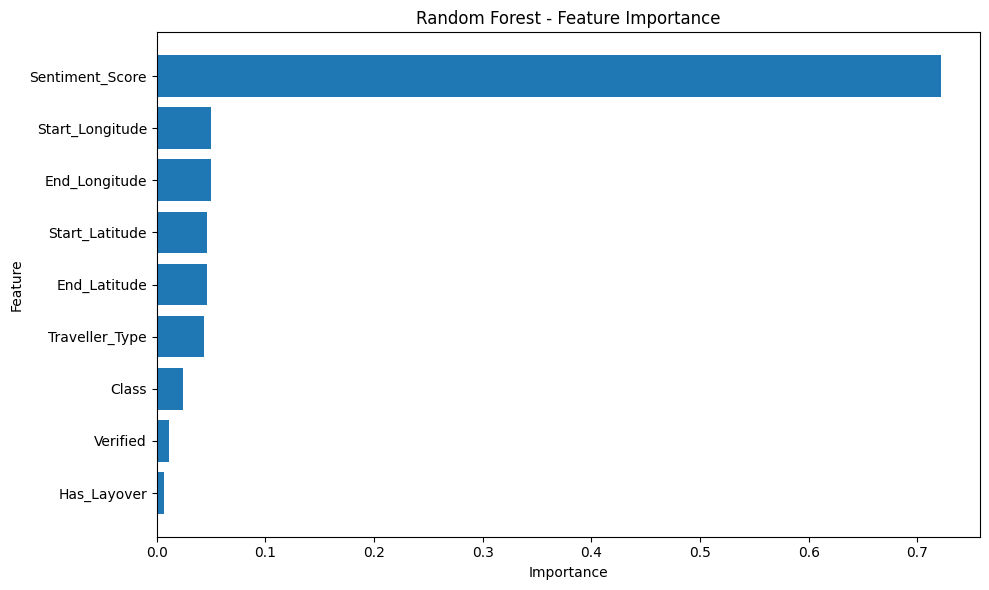


Feature Importance Rankings:
           feature  importance
3  Sentiment_Score    0.721636
6  Start_Longitude    0.050199
8    End_Longitude    0.050162
5   Start_Latitude    0.046534
7     End_Latitude    0.046464
0   Traveller_Type    0.043846
1            Class    0.023727
2         Verified    0.010959
4      Has_Layover    0.006474


In [30]:
# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance)

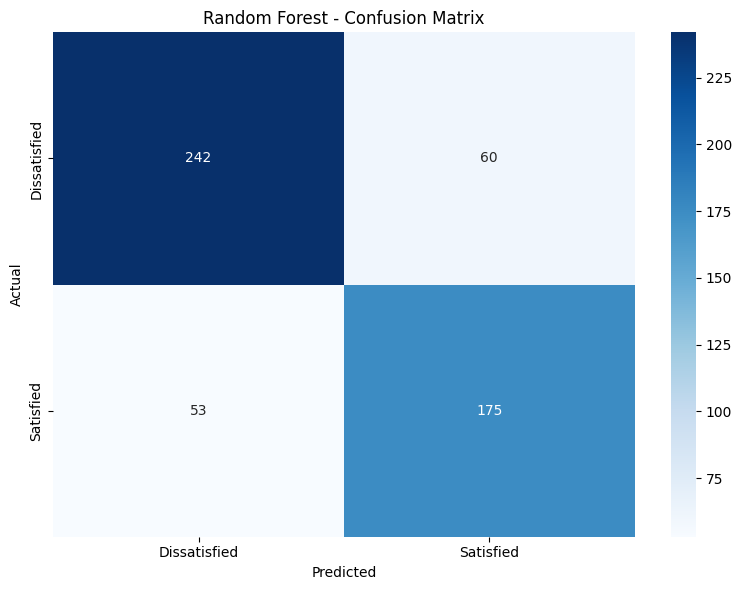

In [31]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [32]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2118, 9)
Test data shape: (530, 9)


In [33]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6316 - loss: 0.6941 - precision: 0.6411 - recall: 0.3509 - val_accuracy: 0.7524 - val_loss: 0.6014 - val_precision: 0.7000 - val_recall: 0.6879
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6316 - loss: 0.6941 - precision: 0.6411 - recall: 0.3509 - val_accuracy: 0.7524 - val_loss: 0.6014 - val_precision: 0.7000 - val_recall: 0.6879
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.5771 - precision: 0.7347 - recall: 0.7168 - val_accuracy: 0.7995 - val_loss: 0.5279 - val_precision: 0.7095 - val_recall: 0.8613
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.5771 - precision: 0.7347 - recall: 0.7168 - val_accuracy: 0.7995 - val_loss: 0.5279 - val_precision: 0.7095 - val_recall: 0.8613
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.5339 - precision: 0.7293 - recall: 0.7995 - val_accuracy:

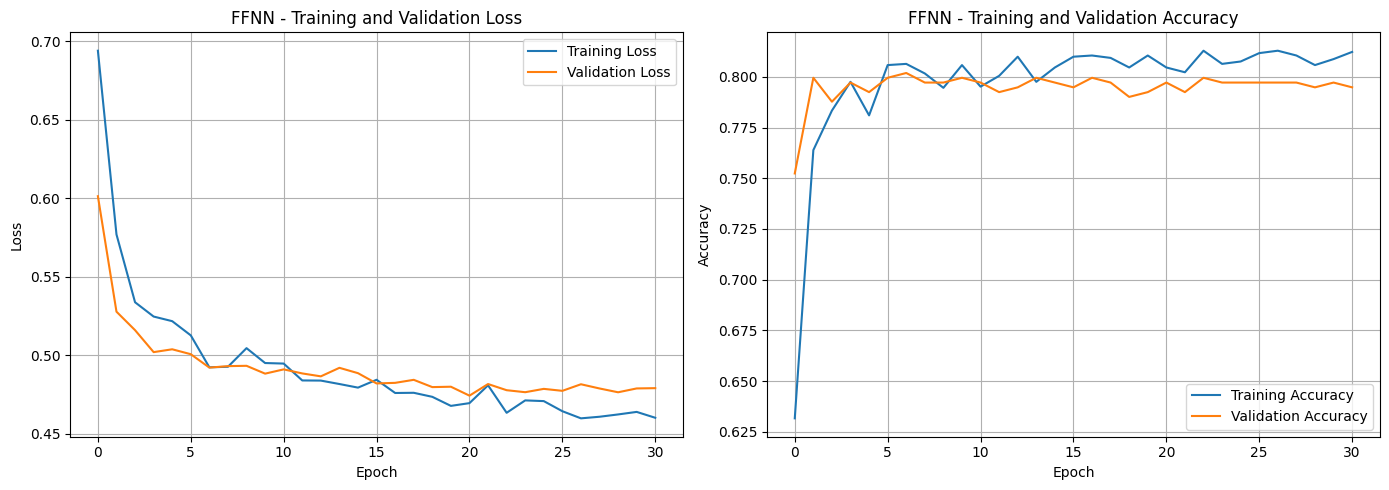

In [35]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [36]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.7962
Precision: 0.7439
Recall:    0.8026
F1-Score:  0.7722

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.79      0.82       302
   Satisfied       0.74      0.80      0.77       228

    accuracy                           0.80       530
   macro avg       0.79      0.80      0.79       530
weighted avg       0.80      0.80      0.80       530

SHALLOW FFNN - RESULTS

Accuracy:  0.7962
Precision: 0.7439
Recall:    0.8026
F1-Score:  0.7722

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.79      0.82       302
   Satisfied       0.74      0.80      0.77       228

    accuracy                           0.80       530
   macro avg       0.79      0.80      0.79       530
weighted avg       0.80      0.80      0.80       530



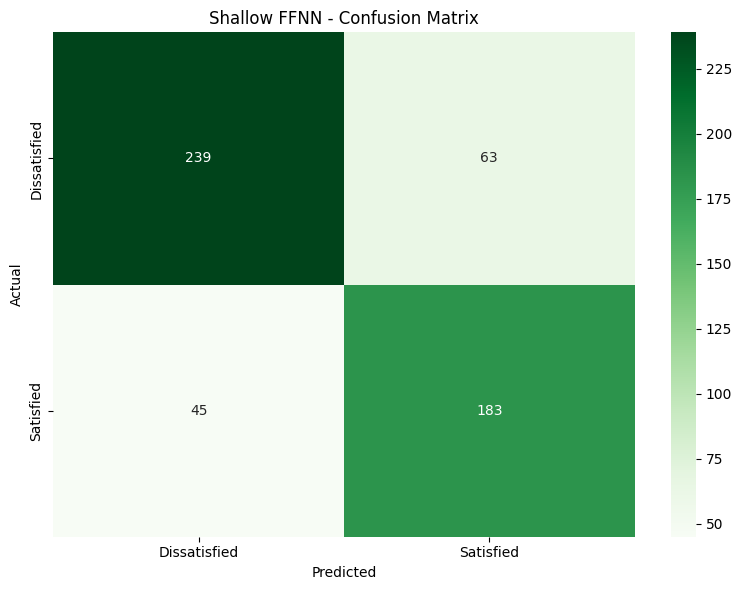

In [37]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 5: Model Comparison and Final Recommendations

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.786792   0.744681 0.767544  0.755940
 Shallow FFNN  0.796226   0.743902 0.802632  0.772152


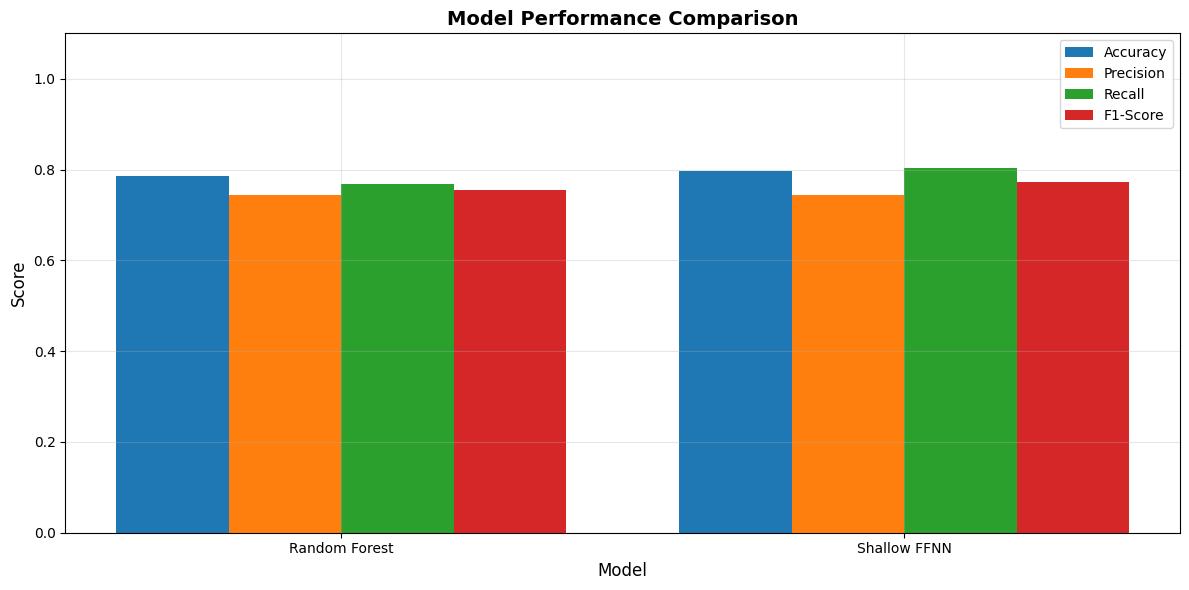

In [38]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Recommendations

### Model Selection Rationale:

#### **Random Forest Classifier** (Statistical ML Model)
**Advantages:**
- ✅ No feature scaling required
- ✅ Provides feature importance insights
- ✅ Handles non-linear relationships naturally
- ✅ Robust against overfitting
- ✅ Faster training on small datasets
- ✅ More interpretable for stakeholders

**Why chosen:**
Random Forest is ideal for this dataset because it can handle the mix of categorical and numerical features without extensive preprocessing, provides clear feature importance rankings (helping identify what drives satisfaction), and is less prone to overfitting with our moderately-sized dataset.

---

#### **Shallow FFNN** (Neural Network)
**Advantages:**
- ✅ Can learn complex non-linear patterns
- ✅ Flexible architecture for optimization
- ✅ Smooth decision boundaries
- ✅ Can be extended to deeper architectures if needed

**Architecture choices:**
- **2 hidden layers (64 → 32 neurons)**: Shallow enough to avoid overfitting, deep enough to learn patterns
- **ReLU activation**: Prevents vanishing gradients and trains faster
- **Dropout layers (0.3, 0.2)**: Regularization to prevent overfitting
- **L2 regularization**: Further prevents overfitting by penalizing large weights
- **Adam optimizer**: Adaptive learning rate for faster convergence
- **Early stopping**: Prevents overfitting by monitoring validation loss

**Why chosen:**
The shallow FFNN provides a good balance between complexity and generalization. It can capture non-linear interactions between features while remaining simple enough to train effectively on our dataset size (~2,600 samples).

---

### Final Recommendation:
Based on the evaluation metrics, **choose the model with higher F1-score** as it balances precision and recall. If interpretability is important, **Random Forest** is preferred. If maximizing predictive accuracy is the goal and computational resources allow, the **Shallow FFNN** may perform better after hyperparameter tuning.